In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import time


def plot_history(history, title="Entrenamiento"):
    plt.figure(figsize=(12, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="train accuracy")
    plt.plot(history.history["val_accuracy"], label="val accuracy")
    plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="train loss")
    plt.plot(history.history["val_loss"], label="val loss")
    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()


#**Empezamos aquí**

Carga y preparación de MNIST

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32")/255.0
x_test = x_test.astype("float32")/255.0

x_train = x_train.reshape(-1, 28,28,1)
x_test = x_test.reshape(-1, 28,28,1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Modelo denso para MNIST



In [ ]:
modelo_denso = models.Sequential([
    layers.Input(shape=(28,28,1)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")

])


modelo_denso.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

modelo_denso.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento el modelo

In [ ]:
historial = modelo_denso.fit(
    x_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1
)



Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9159 - loss: 0.2922 - val_accuracy: 0.9648 - val_loss: 0.1254
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9632 - loss: 0.1219 - val_accuracy: 0.9720 - val_loss: 0.0973
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9747 - loss: 0.0830 - val_accuracy: 0.9762 - val_loss: 0.0807
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9806 - loss: 0.0612 - val_accuracy: 0.9778 - val_loss: 0.0748
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9842 - loss: 0.0494 - val_accuracy: 0.9715 - val_loss: 0.0973
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9879 - loss: 0.0385 - val_accuracy: 0.9757 - val_loss: 0.0859
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9893 - loss: 0.0328 - val_accuracy: 0.9795 - val_loss: 0.0803
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9919 - loss: 0.0248 - val_accuracy: 0.

In [ ]:
test_loss_denso, test_accuracy_denso = modelo_denso.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9747 - loss: 0.1075


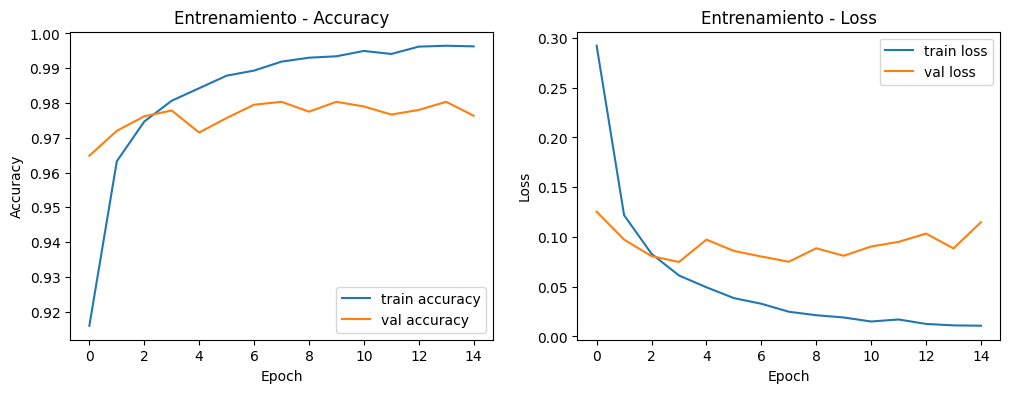

In [ ]:
history_denso=historial

plot_history(history_denso)

## Modelo convolucional para MNIST

In [ ]:
from matplotlib.cbook import flatten
modelo_cnn = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

modelo_denso.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,160 (1.25 MB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 218,774 (854.59 KB)

### Entrenamiento del modelo CNN

In [ ]:

modelo_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
history_cnn = modelo_cnn.fit(
    x_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9447 - loss: 0.1804 - val_accuracy: 0.9823 - val_loss: 0.0638
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9822 - loss: 0.0574 - val_accuracy: 0.9878 - val_loss: 0.0466
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9876 - loss: 0.0406 - val_accuracy: 0.9883 - val_loss: 0.0398
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9901 - loss: 0.0325 - val_accuracy: 0.9907 - val_loss: 0.0379
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9919 - loss: 0.0248 - val_accuracy: 0.9892 - val_loss: 0.0364
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9945 - loss: 0.0173 - val_accuracy: 0.9898 - val_loss: 0.0397
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9948 - loss: 0.0156 - val_accuracy: 0.9910 - val_loss: 0.0343
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9956 - loss: 0.0124 - val_accuracy: 0.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9895 - loss: 0.0375
Acc:  0.9894999861717224
Loss:  0.03753313049674034


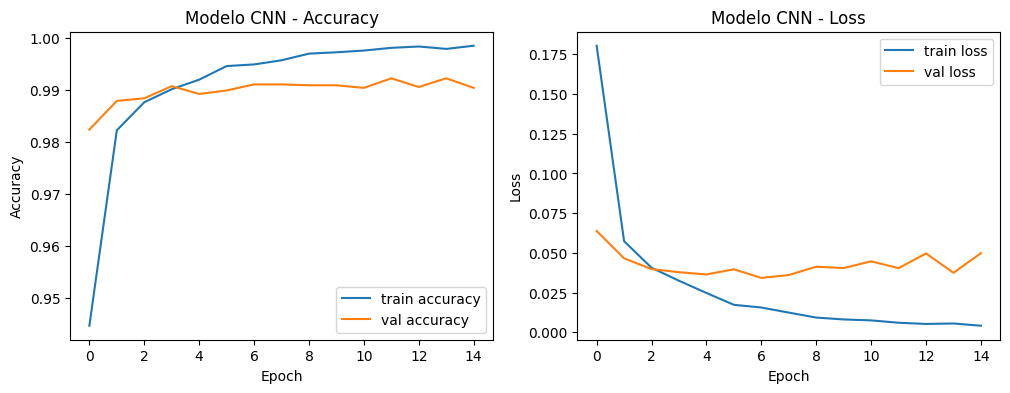

In [ ]:
test_loss_cnn, test_acc_cnn = modelo_cnn.evaluate(x_test, y_test)
print("Acc: ", test_acc_cnn)
print("Loss: ", test_loss_cnn)
plot_history(history_cnn, "Modelo CNN")

## 6. Comparación entre modelo denso y CNN en MNIST

In [ ]:
params_denso = modelo_denso.count_params()
params_cnn = modelo_cnn.count_params()

print("Comparación MNIST")
print("-----------------")

print("Modelo denso")
print("Parámetros:", params_denso)  # Muestra el número de parámetros del modelo denso.


print("Modelo CNN")  # Indica que se mostrarán los resultados del modelo CNN.
print("Accuracy:", round(test_acc_cnn, 4))
print("Parámetros:", params_cnn)

Comparación MNIST
-----------------
Modelo denso
Parámetros: 109386
Modelo CNN
Accuracy: 0.9895
Parámetros: 121930


# **CIFAR-10 con red convolucional**

CIFAR-10 es más difícil que MNIST.


In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

NameError: name 'tf' is not defined

In [ ]:
x_train = x_train.astype("float32")/255
x_test = x_test.astype("float32")/255

y_train = y_train.flatten()
y_test = y_test.flatten()

## 8. Visualización de imágenes de CIFAR-10


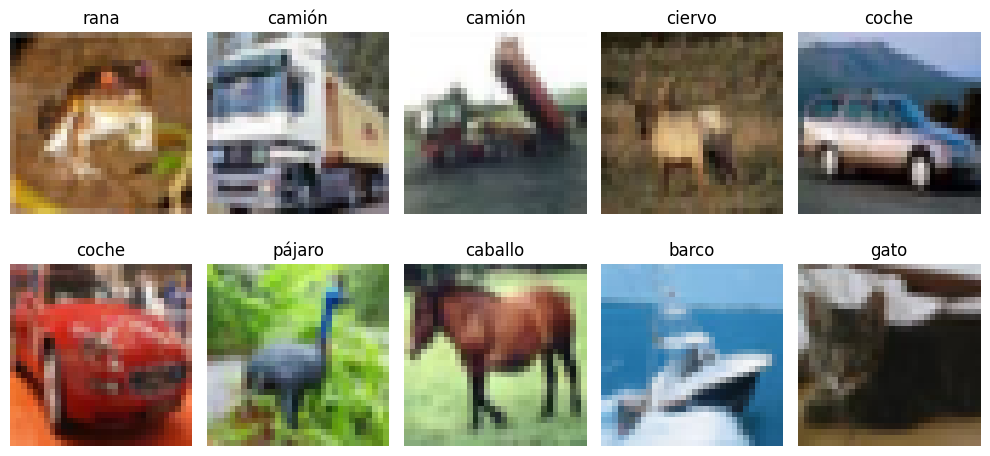

In [ ]:
class_names = [
    "avión",
    "coche",
    "pájaro",
    "gato",
    "ciervo",
    "perro",
    "rana",
    "caballo",
    "barco",
    "camión"
]


plt.figure(figsize=(10,5))
for i in range(10):
  plt.subplot(2, 5, i+1)
  plt.imshow(x_train[i])
  plt.title(class_names[y_train[i]])
  plt.axis("off")


plt.tight_layout()
plt.show()

## CNN para CIFAR-10 sin data augmentation

In [ ]:
modelo_cifar_cnn = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),


    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])


modelo_cifar_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

modelo_cifar_cnn.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,986 (1.54 MB)

 Trainable params: 402,986 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_cifar_cnn = modelo_cifar_cnn.fit(
    x_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1
)


Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.3866 - loss: 1.6576 - val_accuracy: 0.5192 - val_loss: 1.3166
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5632 - loss: 1.2154 - val_accuracy: 0.6436 - val_loss: 1.0143
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6417 - loss: 1.0182 - val_accuracy: 0.6866 - val_loss: 0.9018
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6934 - loss: 0.8847 - val_accuracy: 0.6908 - val_loss: 0.9021
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7242 - loss: 0.7920 - val_accuracy: 0.7392 - val_loss: 0.7406
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7533 - loss: 0.7079 - val_accuracy: 0.7640 - val_loss: 0.6838
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7811 - loss: 0.6330 - val_accuracy: 0.7678 - val_loss: 0.6778
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7952 - loss: 0.5809 - val_accuracy: 

### Entrenamiento de la CNN en CIFAR-10

Usamos 10 épocas. CIFAR-10 es más complejo que MNIST, así que suele necesitar más entrenamiento y arquitecturas más potentes.


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7693 - loss: 0.8191
Loss 0.8191354274749756
Accuracy 0.7692999839782715


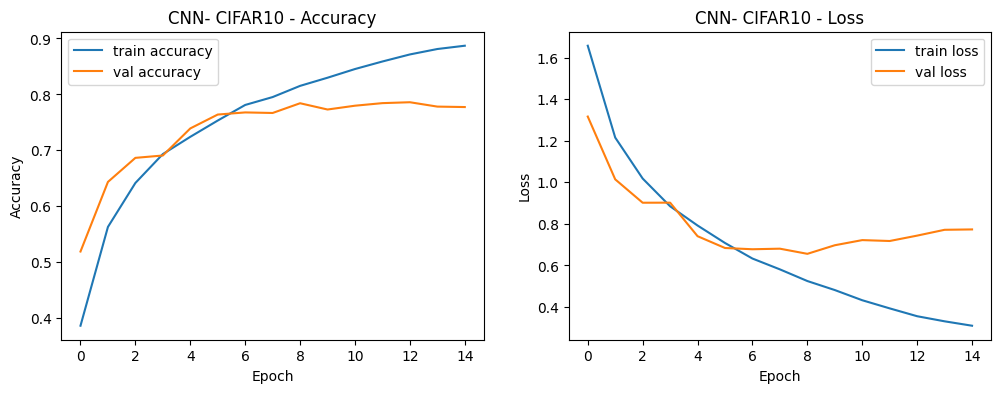

In [ ]:
test_loss_cifar, test_acc_cifar = modelo_cifar_cnn.evaluate(x_test, y_test)
print("Loss", test_loss_cifar)
print("Accuracy", test_acc_cifar)

plot_history(history_cifar_cnn, "CNN- CIFAR10")


# Data augmentation en CIFAR-10

## Definición del data augmentation
- `RandomFlip("horizontal")`: voltea la imagen horizontalmente.
- `RandomRotation(0.1)`: rota ligeramente.
- `RandomZoom(0.1)`: aplica zoom.
- `RandomTranslation(0.1, 0.1)`: desplaza la imagen.


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1)
])

## Visualización del data augmentation

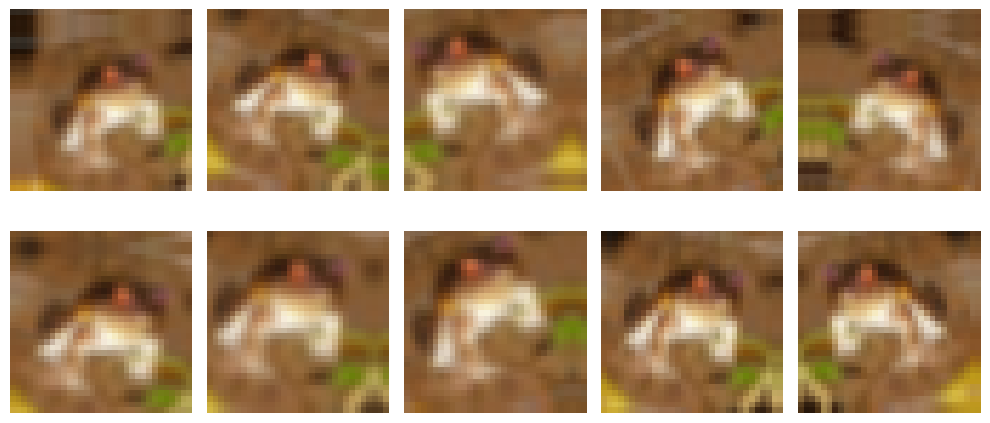

In [ ]:
imagen = x_train[0]
plt.figure(figsize=(10, 5))

for i in range(10):
    imagen_aumentada = data_augmentation(tf.expand_dims(imagen, 0), training=True)

    plt.subplot(2, 5, i + 1)
    plt.imshow(imagen_aumentada[0])
    plt.axis("off")

plt.tight_layout()
plt.show()

## CNN con data augmentation, Batch Normalization y Dropout


In [ ]:
modelo_aug = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    data_augmentation,

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])


modelo_aug.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

modelo_aug.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,29

 Total params: 404,778 (1.54 MB)

 Trainable params: 403,882 (1.54 MB)

 Non-trainable params: 896 (3.50 KB)

### Entrenamiento del modelo con data augmentation

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - accuracy: 0.3593 - loss: 1.8583 - val_accuracy: 0.5052 - val_loss: 1.4120
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.4760 - loss: 1.4506 - val_accuracy: 0.4814 - val_loss: 1.4813
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.5295 - loss: 1.3151 - val_accuracy: 0.5626 - val_loss: 1.2396
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.5666 - loss: 1.2209 - val_accuracy: 0.5994 - val_loss: 1.2261
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.5952 - loss: 1.1462 - val_accuracy: 0.6506 - val_loss: 1.0171
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.6115 - loss: 1.1001 - val_accuracy: 0.6428 - val_loss: 1.0477
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.6250 - loss: 1.0663 - val_accuracy: 0.6436 - val_loss: 1.0354
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.6418 - loss: 1.0273 - 

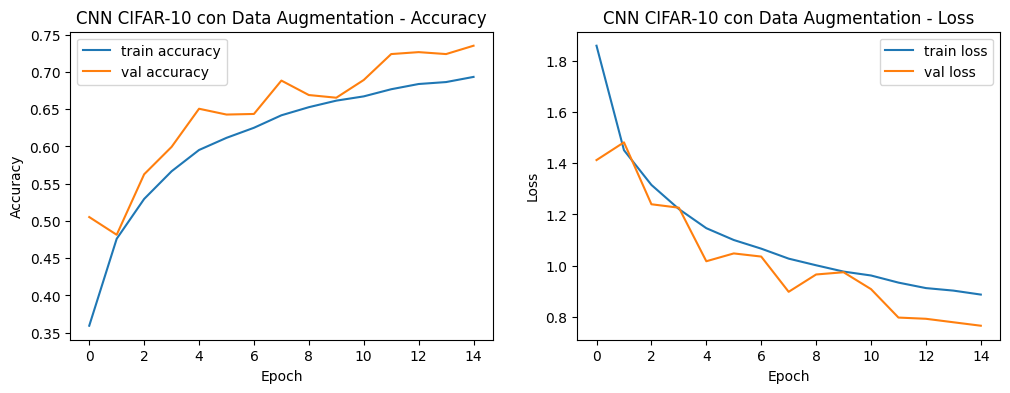

In [ ]:
history_aug = modelo_aug.fit(
    x_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1
)

test_loss_aug, test_acc_aug = modelo_aug.evaluate(x_test, y_test)
print("Accuracy test CIFAR-10 con data augmentation:", test_acc_aug)
plot_history(history_aug, "CNN CIFAR-10 con Data Augmentation")

## Comparación final en CIFAR-10


In [ ]:
print("Comparación CIFAR-10")
print("--------------------")

print("CNN sin data augmentation")
print("Accuracy test:", round(test_acc_cifar, 4))
print()

print("CNN con data augmentation")
print("Accuracy test:", round(test_acc_aug, 4))

Comparación CIFAR-10
--------------------
CNN sin data augmentation
Accuracy test: 0.7693

CNN con data augmentation
Accuracy test: 0.7255


# **Arquitectura CNN propia**

In [ ]:
(mnist_x_train, mnist_y_train), (mnist_x_test, mnist_y_test) = tf.keras.datasets.mnist.load_data()

mnist_x_train = mnist_x_train.astype("float32") / 255.0
mnist_x_test = mnist_x_test.astype("float32") / 255.0

mnist_x_train = mnist_x_train.reshape(-1, 28, 28, 1)
mnist_x_test = mnist_x_test.reshape(-1, 28, 28, 1)

print("MNIST train:", mnist_x_train.shape)
print("MNIST test:", mnist_x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MNIST train: (60000, 28, 28, 1)
MNIST test: (10000, 28, 28, 1)


**Crear filtros manuales**

In [ ]:

def crear_filtros_manual():
    sobel_x = np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ], dtype="float32")

    sobel_y = np.array([
        [-1, -2, -1],
        [ 0,  0,  0],
        [ 1,  2,  1]
    ], dtype="float32")

    laplaciano = np.array([
        [ 0,  1,  0],
        [ 1, -4,  1],
        [ 0,  1,  0]
    ], dtype="float32")

    blur = np.array([
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]
    ], dtype="float32") / 9.0

    filtros = np.stack([sobel_x, sobel_y, laplaciano, blur])
    filtros = filtros[:, :, :, np.newaxis]
    nombres = ["Sobel X", "Sobel Y", "Laplaciano", "Blur"]

    return filtros, nombres


filtros, nombres_filtros = crear_filtros_manual()
print("Forma de los filtros:", filtros.shape)

Forma de los filtros: (4, 3, 3, 1)


Convolución 2D manual

In [ ]:
from numpy.lib.stride_tricks import sliding_window_view
def padding_manual(x, pad_h, pad_w):
    N, H, W, C = x.shape

    x_pad = np.zeros(
        (N, H + 2 * pad_h, W + 2 * pad_w, C),
        dtype=x.dtype
    )

    x_pad[
        :,
        pad_h:pad_h + H,
        pad_w:pad_w + W,
        :
    ] = x

    return x_pad
def extraer_ventanas_manual(x_pad, H, W, kH, kW, C):
    N = x_pad.shape[0]

    ventanas = np.zeros(
        (N, H, W, kH, kW, C),
        dtype=x_pad.dtype
    )

    for n in range(N):
        for i in range(H):
            for j in range(W):
                ventanas[n, i, j, :, :, :] = x_pad[
                    n,
                    i:i + kH,
                    j:j + kW,
                    :
                ]

    return ventanas


def conv2d_same_numpy(x, kernels):
    N, H, W, C = x.shape
    F, kH, kW, Ck = kernels.shape

    assert C == Ck, "El número de canales de la imagen y los filtros debe coincidir"

    pad_h = kH // 2
    pad_w = kW // 2

    x_pad = padding_manual(x, pad_h, pad_w)

    ventanas = extraer_ventanas_manual(
        x_pad,
        H,
        W,
        kH,
        kW,
        C
    )

    salida = np.einsum("nhwabc,fabc->nhwf", ventanas, kernels)
    return salida.astype("float32")

Activación ReLU manual

In [ ]:
def relu_numpy(x):
    return np.maximum(0, x)

In [ ]:

def maxpool2d_numpy(x, pool_size=2):
    N, H, W, C = x.shape
    nuevo_H = H // pool_size
    nuevo_W = W // pool_size

    x = x[:, :nuevo_H * pool_size, :nuevo_W * pool_size, :]

    x = x.reshape(
        N,
        nuevo_H,
        pool_size,
        nuevo_W,
        pool_size,
        C
    )

    salida = x.max(axis=(2, 4))
    return salida

Resultado

In [ ]:
imagen = mnist_x_train[0:1]

mapas_conv = conv2d_same_numpy(imagen, filtros)
mapas_relu = relu_numpy(mapas_conv)
mapas_pool = maxpool2d_numpy(mapas_relu)

print("Imagen original:", imagen.shape)
print("Después de convolución:", mapas_conv.shape)
print("Después de ReLU:", mapas_relu.shape)
print("Después de max pooling:", mapas_pool.shape)

Imagen original: (1, 28, 28, 1)
Después de convolución: (1, 28, 28, 4)
Después de ReLU: (1, 28, 28, 4)
Después de max pooling: (1, 14, 14, 4)


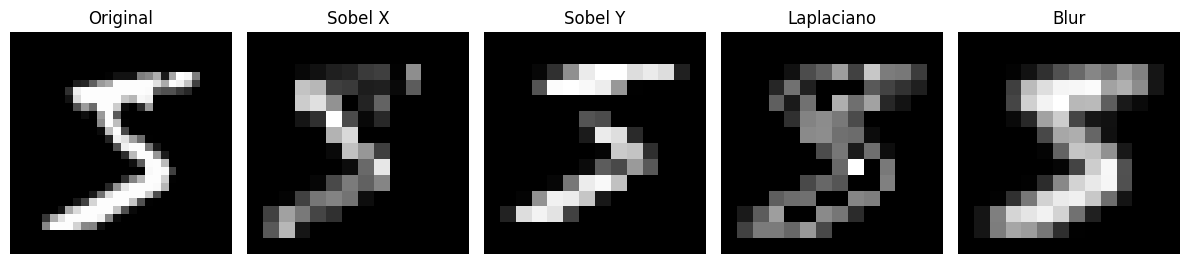

In [ ]:
plt.figure(figsize=(12, 3))

plt.subplot(1, 5, 1)
plt.imshow(imagen[0, :, :, 0], cmap="gray")
plt.title("Original")
plt.axis("off")

for i in range(4):
    plt.subplot(1, 5, i + 2)
    plt.imshow(mapas_pool[0, :, :, i], cmap="gray")
    plt.title(nombres_filtros[i])
    plt.axis("off")

plt.tight_layout()
plt.show()